# Loss-Making Orders Analysis

## Objective

Identify all loss-making orders and analyze the possible reasons behind the losses using:
- Discount
- Product Category
- Shipping Cost

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datas/cleaned_ecommerce.csv")

In [2]:
loss_orders = df[df["Profit"] < 0]

loss_orders.head()

,Order ID,Order Date,Ship Date,Aging,Ship Mode,Product Category,Product,Sales,Quantity,Discount,...,Shipping Cost,Order Priority,Customer ID,Customer Name,Segment,City,State,Country,Region,Months


In [3]:
print("Total Loss-Making Orders:", len(loss_orders))

Total Loss-Making Orders: 0


In [4]:
print("=" * 50)
print(f"Total Loss Orders : {len(loss_orders)}")
print(f"Total Loss Amount : ${loss_orders['Profit'].sum():,.2f}")
print(f"Average Discount  : {loss_orders['Discount'].mean():.2f}")
print(f"Average Shipping Cost : ${loss_orders['Shipping Cost'].mean():.2f}")

Total Loss Orders : 0
Total Loss Amount : $0.00
Average Discount  : nan
Average Shipping Cost : $nan


In [5]:
category_loss = (
    loss_orders.groupby("Product Category")
    .agg(
        Total_Loss=("Profit", "sum"),
        Orders=("Order ID", "count")
    )
    .sort_values(by="Total_Loss")
)

category_loss

,Total_Loss,Orders
Product Category,,


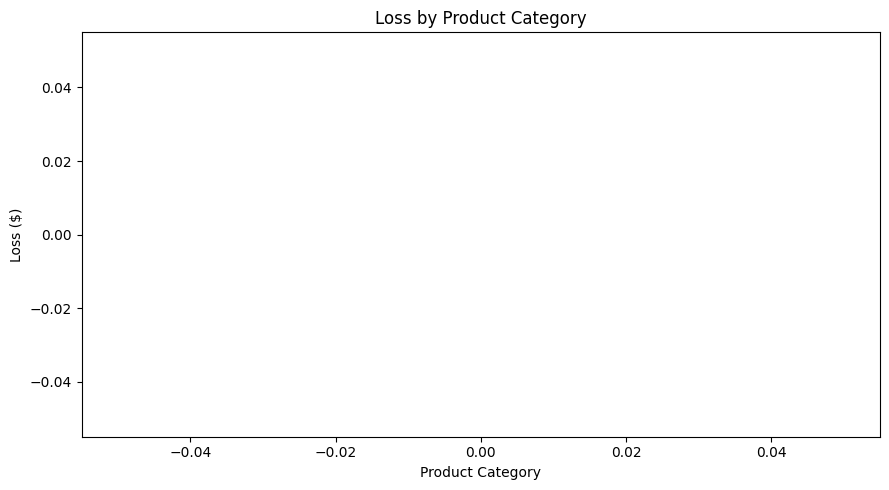

In [6]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    category_loss.index,
    category_loss["Total_Loss"]
)

plt.title("Loss by Product Category")

plt.xlabel("Product Category")
plt.ylabel("Loss ($)")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"${bar.get_height():,.0f}",
        ha="center",
        va="top"
    )

plt.tight_layout()

plt.savefig("../charts/loss_by_category.png", dpi=300)

plt.show()

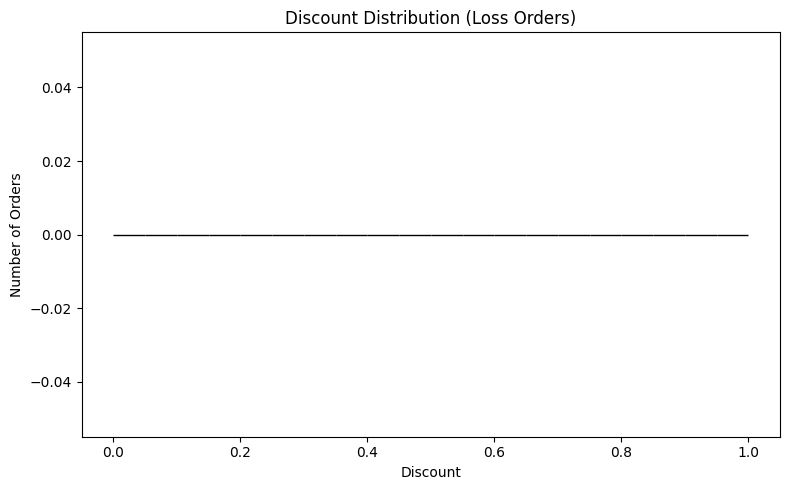

In [8]:
plt.figure(figsize=(8,5))

plt.hist(
    loss_orders["Discount"],
    bins=20,
    edgecolor="black"
)

plt.title("Discount Distribution (Loss Orders)")
plt.xlabel("Discount")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig("../charts/loss_discount_distribution.png", dpi=300)

plt.show()

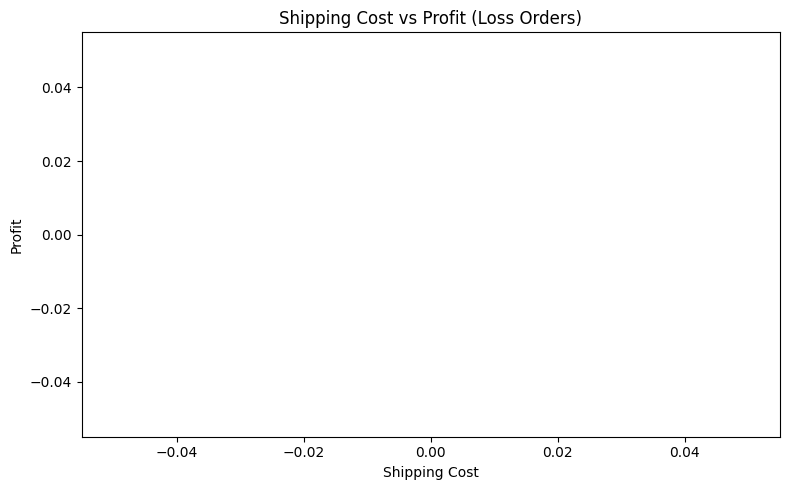

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    loss_orders["Shipping Cost"],
    loss_orders["Profit"],
    alpha=0.6
)

plt.title("Shipping Cost vs Profit (Loss Orders)")
plt.xlabel("Shipping Cost")
plt.ylabel("Profit")

plt.tight_layout()

plt.savefig("../charts/shipping_cost_vs_loss.png", dpi=300)

plt.show()

In [10]:
top_loss_products = (
    loss_orders.groupby("Product")
    .agg(
        Total_Loss=("Profit", "sum")
    )
    .sort_values(by="Total_Loss")
    .head(10)
)

top_loss_products

,Total_Loss
Product,


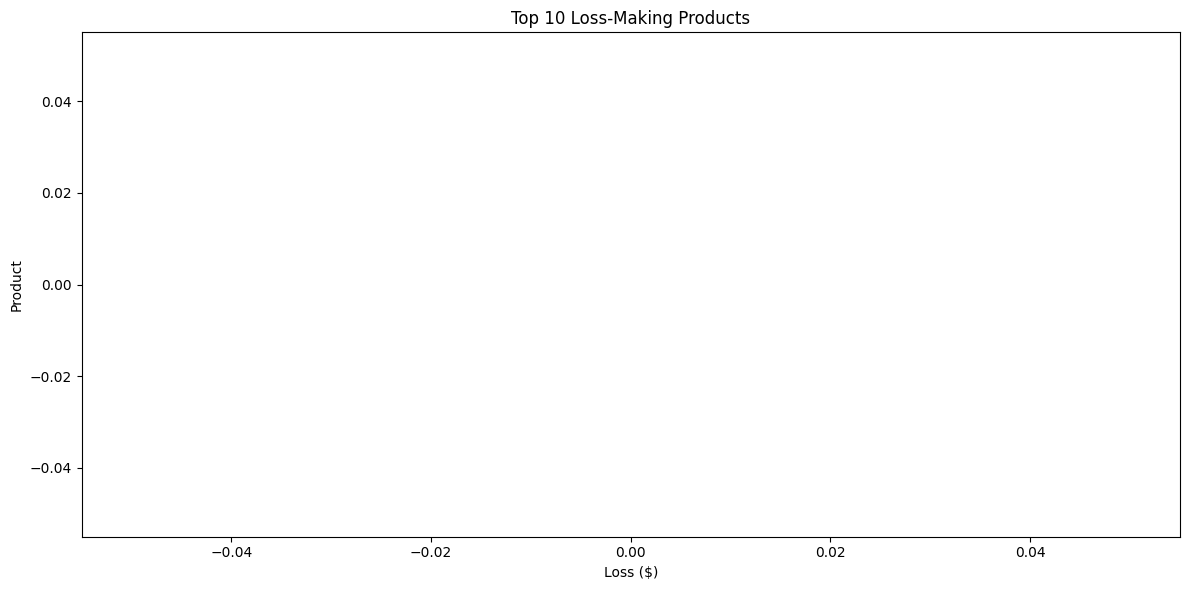

In [11]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    top_loss_products.index,
    top_loss_products["Total_Loss"]
)

plt.title("Top 10 Loss-Making Products")

plt.xlabel("Loss ($)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../charts/top_loss_products.png", dpi=300)

plt.show()

## Business Insights

- Identified all orders with negative profit.
- Analyzed average discounts on loss-making orders.
- Compared losses across product categories.
- Investigated the relationship between shipping cost and losses.
- Identified the top 10 products responsible for the highest losses.

### Recommendations

- Review products with consistently negative profit margins.
- Reassess discount strategies for heavily discounted products.
- Optimize shipping costs for low-margin orders.
- Focus on improving profitability in categories with the highest losses.